#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
path = '/content/drive/MyDrive/bootcamp_eda_study/application_data.csv'
path2 = '/content/drive/MyDrive/bootcamp_eda_study/previous_application.csv'

In [6]:
prev_app = pd.read_csv(path2)
appli = pd.read_csv(path)

In [7]:
appli.shape

(307511, 122)

In [8]:
prev_app.shape

(1670214, 37)

In [9]:
prev_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
appli.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


***FINAL DATASET:*** merging the application and the prev application together based off of loan ID (SK_ID_CURR)

In [11]:
final_dataset = pd.merge(prev_app, appli, how = "inner", on = "SK_ID_CURR")

In [12]:
final_dataset.shape

(1413701, 158)

In [13]:
final_dataset.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE_x,AMT_ANNUITY_x,AMT_APPLICATION,AMT_CREDIT_x,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE_x,WEEKDAY_APPR_PROCESS_START_x,HOUR_APPR_PROCESS_START_x,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,0,0,0,0,0.0,0.0,0.0,1.0,2.0,8.0


***TESTING TARGET***: Seeing how contract status and contract type affects defaulting(TARGET)

<Axes: xlabel='NAME_CONTRACT_STATUS', ylabel='percent'>

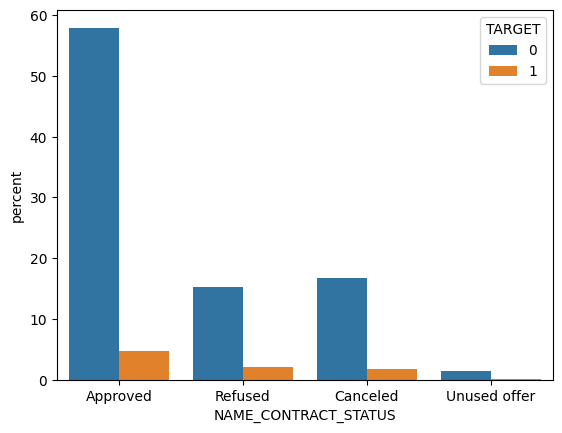

In [14]:
sns.countplot(data=final_dataset, x = "NAME_CONTRACT_STATUS", hue = "TARGET", stat = "percent")

<Axes: xlabel='NAME_CONTRACT_TYPE_x', ylabel='percent'>

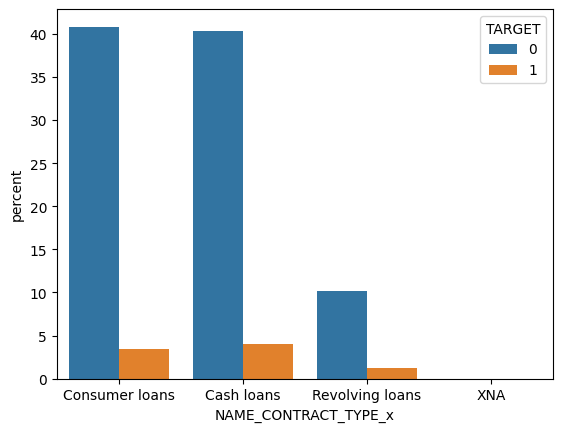

In [15]:
sns.countplot(data = final_dataset, x = "NAME_CONTRACT_TYPE_x", stat = "percent", hue="TARGET")

***TESTING APPLICATION START TIMES:*** Testing the relationship between time that applicants started the form and
contract type or against defaulting.

<Axes: xlabel='HOUR_APPR_PROCESS_START_x', ylabel='percent'>

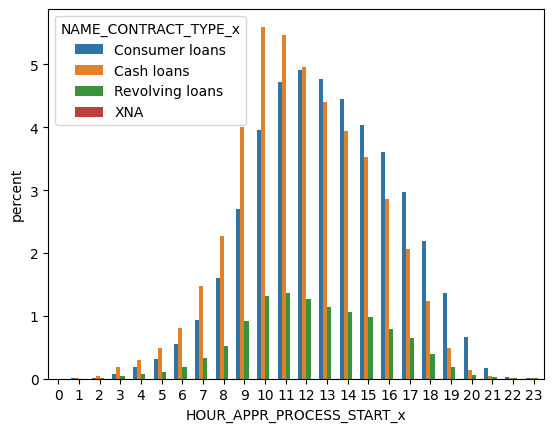

In [16]:
sns.countplot(data =final_dataset, x = "HOUR_APPR_PROCESS_START_x", hue = "NAME_CONTRACT_TYPE_x", stat = "percent")

<Axes: xlabel='HOUR_APPR_PROCESS_START_x', ylabel='percent'>

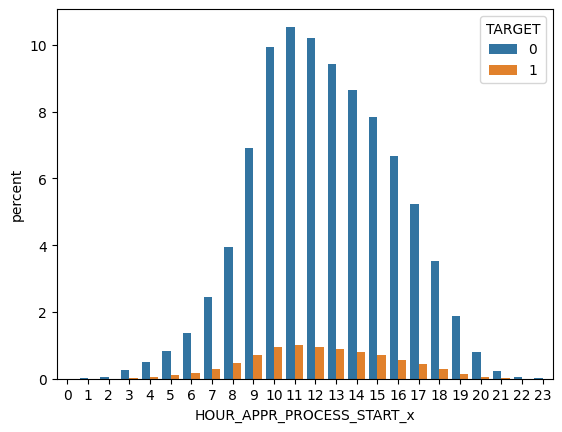

In [ ]:
sns.countplot(data =final_dataset, x = "HOUR_APPR_PROCESS_START_x", hue = "TARGET", stat = "percent")

Applicants tend to start cash loan applications in the morning, and their consumer loan applications in the afternoon(after 12pm)

In [ ]:
print(sns.color_palette("tab10").as_hex())

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


In [22]:
early_birds = final_dataset.loc[(final_dataset["HOUR_APPR_PROCESS_START_x"] < 12) & ((final_dataset["HOUR_APPR_PROCESS_START_x"] > 5))]
mid_day = final_dataset.loc[(final_dataset["HOUR_APPR_PROCESS_START_x"] > 11) & ((final_dataset["HOUR_APPR_PROCESS_START_x"] <18 ))]
night_owls = final_dataset.loc[(final_dataset["HOUR_APPR_PROCESS_START_x"] > 17) & ((final_dataset["HOUR_APPR_PROCESS_START_x"] <24 ))]
custom_palette = {'Approved': '#2ca02c', 'Canceled':'#d62728', 'Refused': '#1f77b4', 'Unused offer': '#ff7f0e'}

Text(0.5, 0, 'Morning Hours')

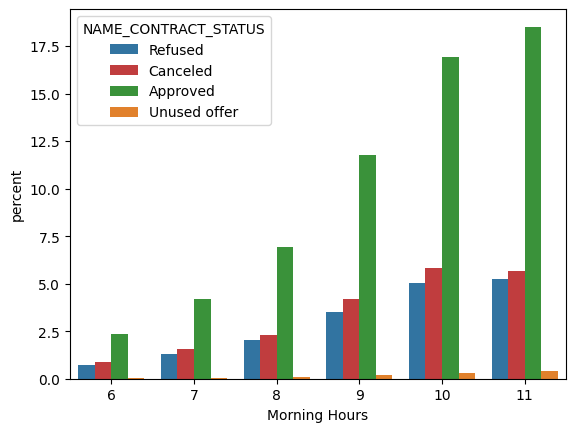

In [ ]:
sns.countplot(data =early_birds, x = "HOUR_APPR_PROCESS_START_x", hue = "NAME_CONTRACT_STATUS", stat = "percent", palette = custom_palette)
plt.xlabel("Morning Hours")

Text(0.5, 0, 'Afternoon Hours')

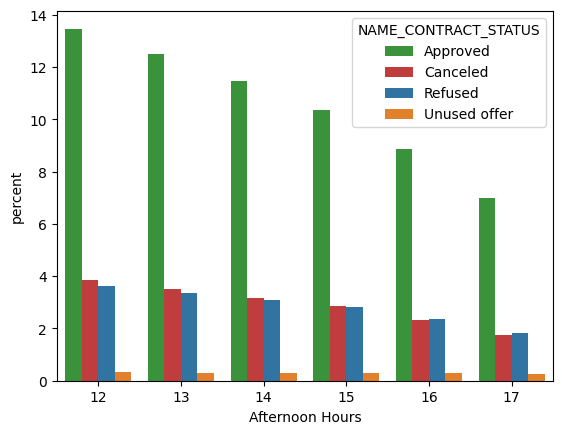

In [ ]:
sns.countplot(data=mid_day, x = "HOUR_APPR_PROCESS_START_x", hue = "NAME_CONTRACT_STATUS", stat = "percent", palette=custom_palette)
plt.xlabel("Afternoon Hours")

Text(0.5, 0, 'Evening Hours')

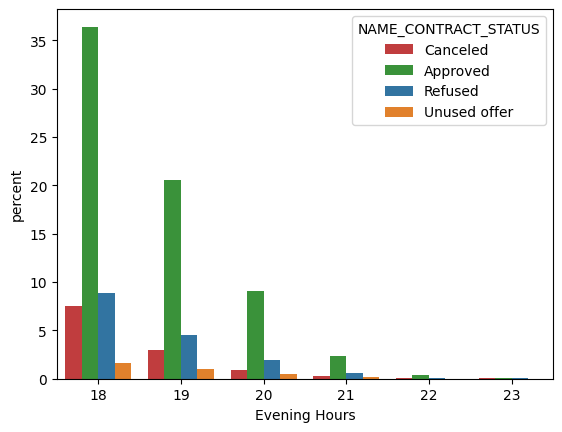

In [ ]:
sns.countplot(data =night_owls, x = "HOUR_APPR_PROCESS_START_x", hue = "NAME_CONTRACT_STATUS", stat = "percent", palette=custom_palette)
plt.xlabel("Evening Hours")

<Axes: xlabel='HOUR_APPR_PROCESS_START_x', ylabel='percent'>

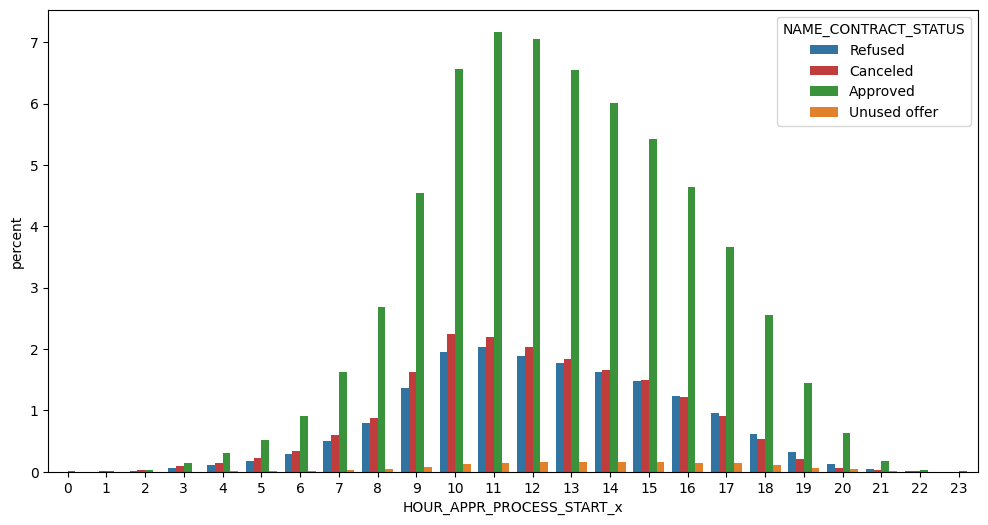

In [24]:
plt.figure(figsize=(12,6))
sns.countplot(data =final_dataset, x = "HOUR_APPR_PROCESS_START_x", hue = "NAME_CONTRACT_STATUS", stat = "percent", palette=custom_palette)

In [ ]:
weekday_order = ['MONDAY', 'TUESDAY', 'WEDNESDAY', 'THURSDAY', 'FRIDAY', 'SATURDAY', 'SUNDAY']
final_dataset['WEEKDAY_APPR_PROCESS_START_x'] = pd.Categorical(
    final_dataset['WEEKDAY_APPR_PROCESS_START_x'],
    categories=weekday_order,
    ordered=True
)

Applicants are more likely to start their consumer loans on the weekends and their cash loans during weekdays.

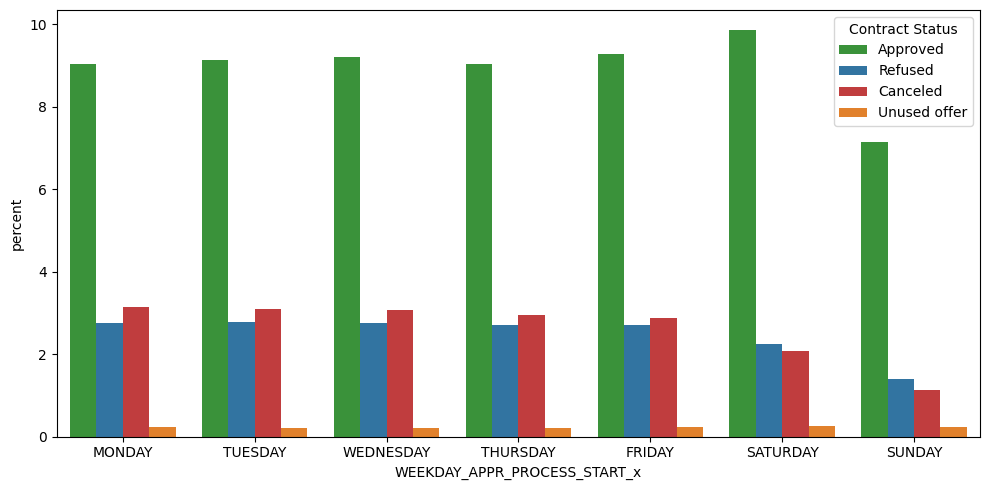

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data =final_dataset, x = "WEEKDAY_APPR_PROCESS_START_x", hue = "NAME_CONTRACT_STATUS", stat = "percent", palette=custom_palette)
plt.legend(title='Contract Status')
plt.tight_layout()

Most loan applications are cancelled more during the weekdays than the weekends. Most loans are approved on Saturdays, less loans are approved on Sundays.

<Axes: xlabel='WEEKDAY_APPR_PROCESS_START_x', ylabel='percent'>

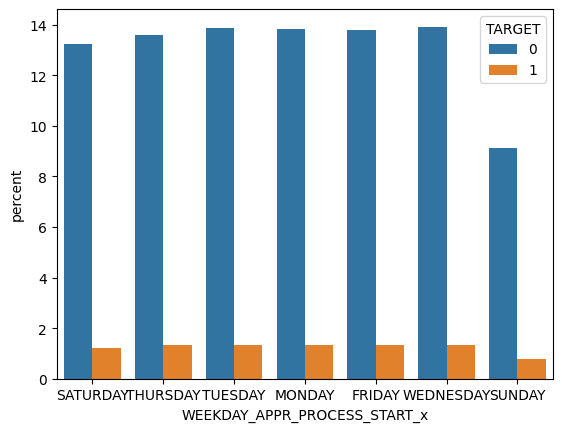

In [ ]:
sns.countplot(data =final_dataset, x = "WEEKDAY_APPR_PROCESS_START_x", hue = "TARGET", stat = "percent")

***TESTING RELATIONSHIPS WITH AGE***

In [17]:
final_dataset["AGE_YRS"] = np.floor(abs((final_dataset["DAYS_BIRTH"]/365))).astype(int)
final_dataset["AGE_YRS"]

,AGE_YRS
0,39
1,58
2,28
3,60
4,27
...,...
1413696,47
1413697,42
1413698,50
1413699,55


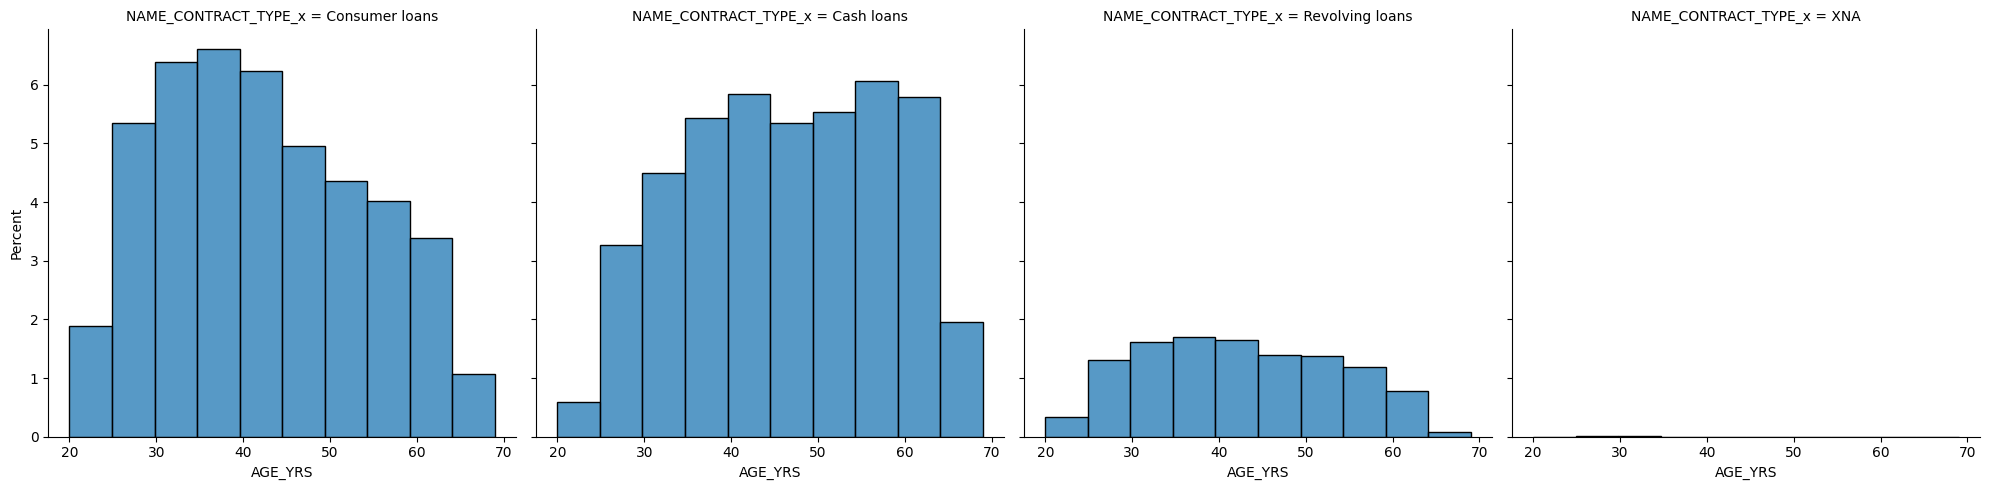

In [19]:
sns.displot(kind = "hist", data = final_dataset, x = "AGE_YRS", stat= "percent"
            ,bins = 10, col="NAME_CONTRACT_TYPE_x")

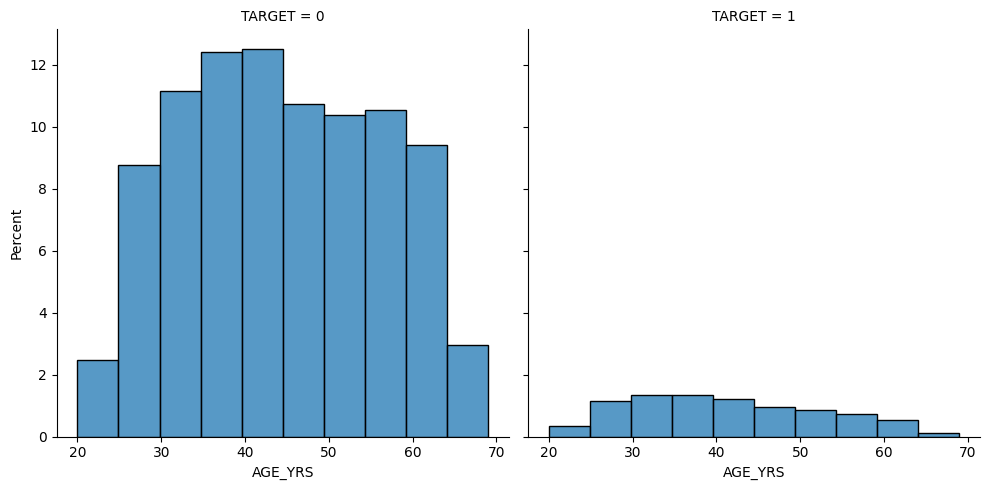

In [20]:
sns.displot(kind = "hist", data = final_dataset, x = "AGE_YRS", stat= "percent"
            ,bins = 10, col="TARGET")

People in the age range from 35 to 40 are more likely to apply for consumer loans or revolving loans, while 55 to 60 year olds are applying for cash loans